In [21]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [22]:
#now loading the csv
from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

Saving social_media_user_behavior - social_media_user_behavior.csv to social_media_user_behavior - social_media_user_behavior (2).csv


In [23]:
import pandas as pd
import numpy as np

df = pd.read_csv('social_media_user_behavior - social_media_user_behavior (1).csv')

print('Shape:', df.shape)           # rows x columns
print('Nulls:', df.isnull().sum().sum())  # total missing values
print()
print('First 3 rows:')
print(df[['user_id','daily_screen_time_minutes','likes_per_day',
          'comments_per_day','shares_per_week','engagement_rate_pct',
          'weekly_sessions','addiction_level_1_to_10']].head(3).to_string())

# now we're making feature 1 thats how user interact with social media
df['engagement_intensity'] = (df['likes_per_day'] + (df['comments_per_day'] * 2) +(df['shares_per_week'] / 7))

#feature 2 (video ratio)
df['video_ratio'] = (df['video_consumption_daily_minutes'] / df['daily_screen_time_minutes']).clip(0, 1)

#feature 3 (posting rate)
df['posting_rate'] = df['posts_per_week'] / (df['weekly_sessions'] + 1)

#feature 4 (log followers)
df['log_followers'] = np.log1p(df['followers_count'])  # log1p = log(1 + x), handles 0s safely

Shape: (25000, 45)
Nulls: 0

First 3 rows:
      user_id  daily_screen_time_minutes  likes_per_day  comments_per_day  shares_per_week  engagement_rate_pct  weekly_sessions  addiction_level_1_to_10
0  USR-000001                         89             29                 2                6                 0.54                6                        1
1  USR-000002                        161             40                 0                0                 2.44               12                        2
2  USR-000003                        342              4                 0                1                 1.67               22                        7


In [24]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

df = pd.read_csv('social_media_user_behavior - social_media_user_behavior.csv')

# Rebuild features
df['engagement_intensity'] = df['likes_per_day'] + (df['comments_per_day'] * 2) + (df['shares_per_week'] / 7)
df['video_ratio'] = (df['video_consumption_daily_minutes'] / df['daily_screen_time_minutes']).clip(0, 1)
df['posting_rate'] = df['posts_per_week'] / (df['weekly_sessions'] + 1)
df['log_followers'] = np.log1p(df['followers_count'])

# Features
features = [
    'daily_screen_time_minutes',
    'weekly_sessions',
    'engagement_intensity',
    'video_ratio',
    'posting_rate',
    'log_followers',
    'addiction_level_1_to_10',
    'monthly_social_spending_usd'
]

X = df[features]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Before scaling (raw):')
print(X.describe().round(1).loc[['mean','std','min','max']].to_string())

print('\nAfter scaling (standardized):')
scaled_df = pd.DataFrame(X_scaled, columns=features)
print(scaled_df.describe().round(2).loc[['mean','std','min','max']].to_string())

Before scaling (raw):
      daily_screen_time_minutes  weekly_sessions  engagement_intensity  video_ratio  posting_rate  log_followers  addiction_level_1_to_10  monthly_social_spending_usd
mean                      141.1              9.0                  17.0          0.5           0.4            5.5                      2.9                         11.9
std                        62.6              4.9                  13.4          0.2           0.7            2.0                      1.7                         11.9
min                         5.0              1.0                   0.0          0.0           0.0            0.0                      1.0                          0.0
max                       467.0             31.0                 119.4          1.0          14.0           13.2                     10.0                        120.7

After scaling (standardized):
      daily_screen_time_minutes  weekly_sessions  engagement_intensity  video_ratio  posting_rate  log_followers

✅ Block 1 — Libraries imported
✅ Block 2 — Data loaded (25K rows, zero nulls)
✅ Block 3 — 4 new features engineered
✅ Block 4 — 8 features selected & scaled

In [25]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias   = []
sil_scores = []
K_range    = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)

    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels, sample_size=5000, random_state=42))

# Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Elbow curve
ax1.plot(list(K_range), inertias, 'o-', color='#7c6af7', linewidth=2.5)
ax1.axvline(x=5, color='#f76c6c', linestyle='--', label='Elbow @ k=5')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.legend()

# Silhouette curve
ax2.plot(list(K_range), sil_scores, 's-', color='#43e97b', linewidth=2.5)
ax2.axvline(x=3, color='#f7c96c', linestyle='--', label='Best silhouette @ k=3')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score (higher = better)')
ax2.legend()

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# TRAIN KMEANS WITH k=5

km_final = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_scaled)

print(df['cluster'].value_counts().sort_index())

cluster
0    5882
1    7088
2    1142
3    8183
4    2705
Name: count, dtype: int64


In [27]:
# 7 PROFILE EACH CLUSTER

profile_cols = ['daily_screen_time_minutes', 'weekly_sessions',
                'engagement_intensity', 'video_ratio', 'posting_rate',
                'log_followers', 'addiction_level_1_to_10',
                'monthly_social_spending_usd']

profile = df.groupby('cluster')[profile_cols].mean().round(2)
print(profile.to_string())

         daily_screen_time_minutes  weekly_sessions  engagement_intensity  video_ratio  posting_rate  log_followers  addiction_level_1_to_10  monthly_social_spending_usd
cluster                                                                                                                                                                  
0                           103.24             6.38                 16.36         0.35          0.38           5.57                     1.94                         8.63
1                           107.54             6.65                 17.30         0.71          0.37           5.48                     1.98                         8.55
2                            73.92             2.30                 17.01         0.54          2.92           5.49                     1.82                        11.52
3                           206.01            13.81                 17.01         0.54          0.22           5.49                     4.52          

In [28]:
#VISUALIZING CLUSTERS WITH PCA

from sklearn.decomposition import PCA

pca        = PCA(n_components=2)
X_pca      = pca.fit_transform(X_scaled)

# explained_variance_ratio_ tells how much info is preserved
print(f'Variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%')

Variance explained: 44.6%


In [29]:
X_scaled
km = KMeans(...)
df['cluster']

,cluster
0,1
1,1
2,3
3,0
4,1
...,...
24995,0
24996,1
24997,0
24998,4


In [30]:
# KMeans
k = 5

km = KMeans(n_clusters=k, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(X_scaled)

In [31]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA

# PCA
pca        = PCA(n_components=2, random_state=42)
X_pca      = pca.fit_transform(X_scaled)
df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

# Colors & names
COLORS = {0:'#a78bfa', 1:'#60a5fa', 2:'#34d399', 3:'#f87171', 4:'#fbbf24'}
NAMES  = {0:'Casual Non-Video Users', 1:'Light Video Consumers',
          2:'Micro Creators', 3:'Heavy Addicted Users', 4:'Social Shoppers'}

# Plot
fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')
ax.tick_params(colors='#aaaaaa')
for spine in ax.spines.values():
    spine.set_edgecolor('#333')

for c in range(5):
    mask = df['cluster'] == c
    ax.scatter(df.loc[mask,'pca1'], df.loc[mask,'pca2'],
               c=COLORS[c], s=8, alpha=0.45, linewidths=0)

centers_pca = pca.transform(km.cluster_centers_)
for c in range(5):
    ax.scatter(centers_pca[c,0], centers_pca[c,1],
               c=COLORS[c], s=300, marker='*', edgecolors='white', zorder=5)
    ax.annotate(f'  {NAMES[c]}', (centers_pca[c,0], centers_pca[c,1]),
                color='white', fontsize=8.5, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#1a1d27',
                          edgecolor=COLORS[c], alpha=0.85))

legend_handles = [mpatches.Patch(facecolor=COLORS[c], label=f'{NAMES[c]}') for c in range(5)]
ax.legend(handles=legend_handles, facecolor='#1a1d27', edgecolor='#444', labelcolor='white')
ax.set_title('Social Media User Segments — KMeans k=5',
             color='white', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('clusters.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

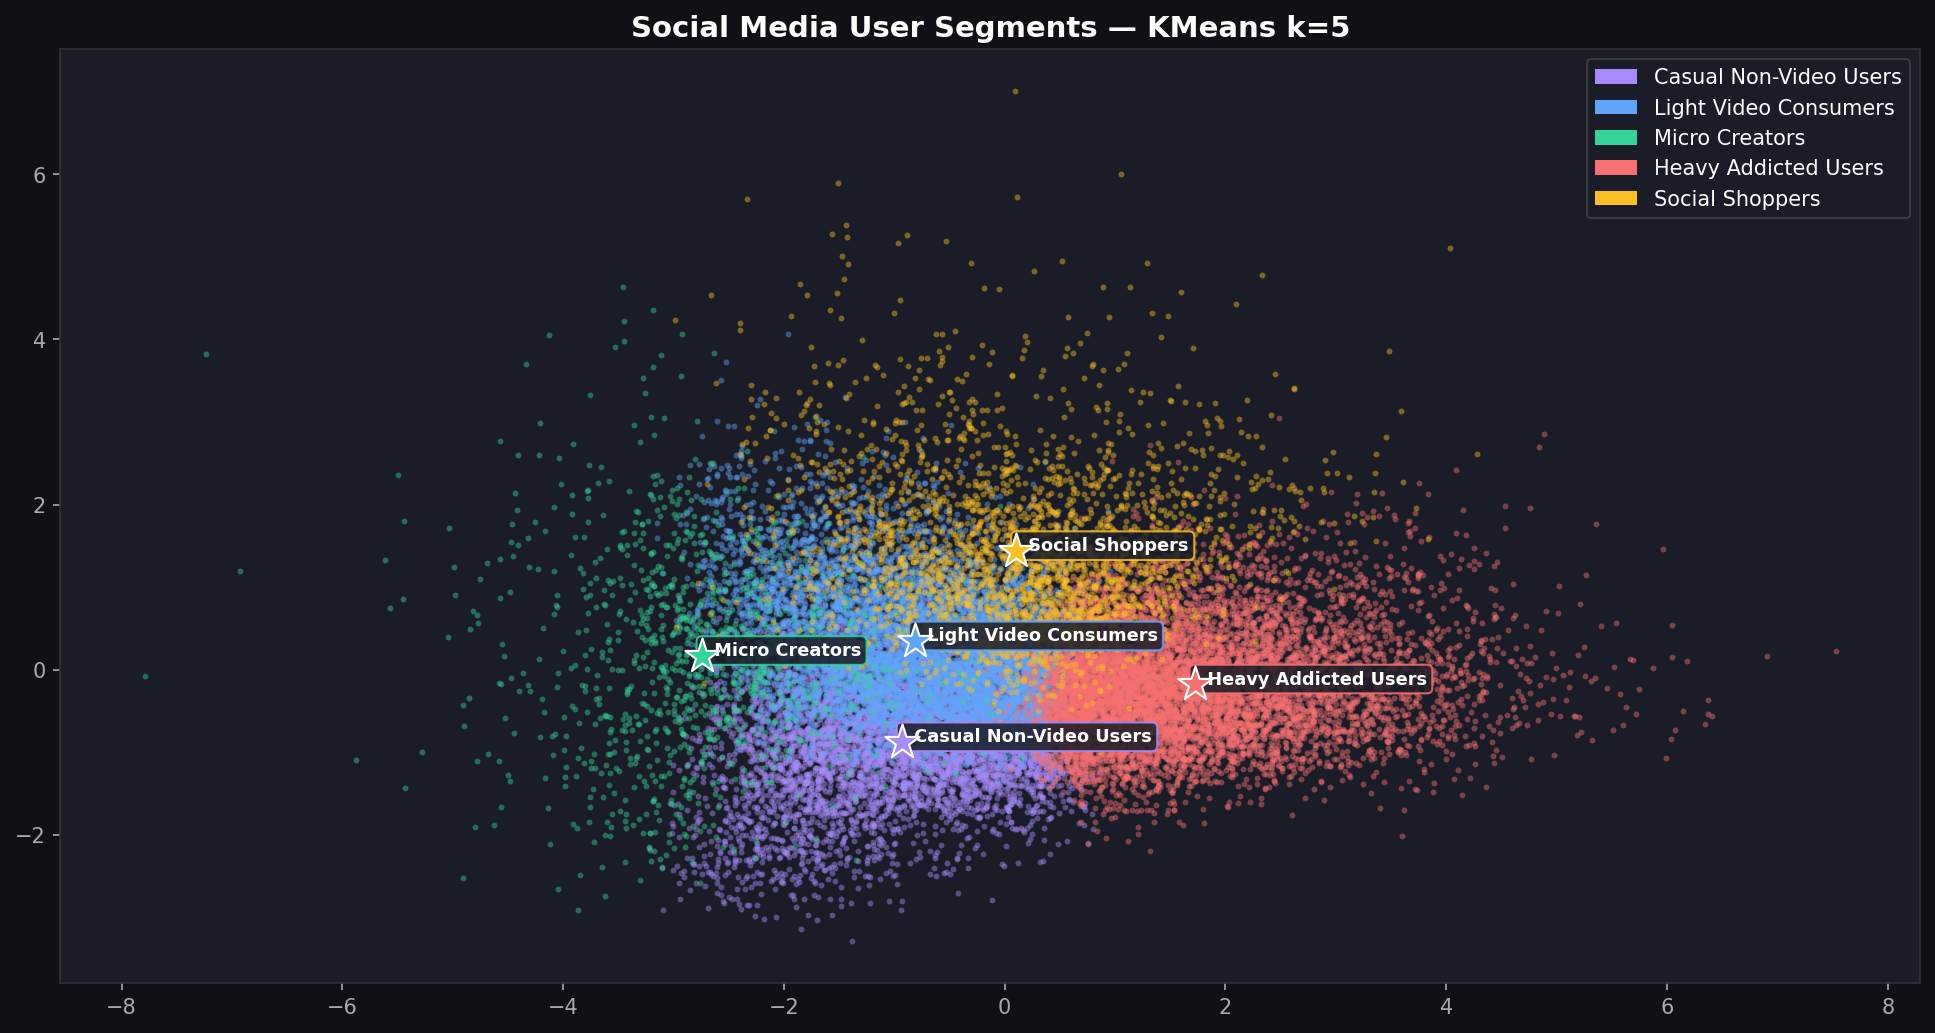

In [32]:
from PIL import Image
from IPython.display import display

img = Image.open('clusters.png')
display(img)